#Part C — Actionable output

## Strategy 1 — Consistent Winners should trade more on Fear days

Consistent winners (win rate ≥ 50%) show higher avg PnL and win rate during Fear compared to Greed days.

Rule of thumb:
If sentiment = Fear increase trade frequency for consistent winner accounts
If sentiment = Greed reduce activity or tighten stop losses

## Strategy 2 — High-leverage infrequent traders should cap leverage on Greed days

High leverage + infrequent traders produce negative avg PnL on Greed days.
Low leverage + frequent traders stay profitable across all sentiment conditions.

Rule of thumb:
If sentiment = Greed and trader is infrequent cap leverage to 1× baseline
Prefer low-leverage, consistent-frequency approach during Greed periods

#Predictive Model

Classification Report:
              precision    recall  f1-score   support

    Loss Day       0.00      0.00      0.00        10
  Profit Day       0.89      0.94      0.92        86

    accuracy                           0.84        96
   macro avg       0.45      0.47      0.46        96
weighted avg       0.80      0.84      0.82        96



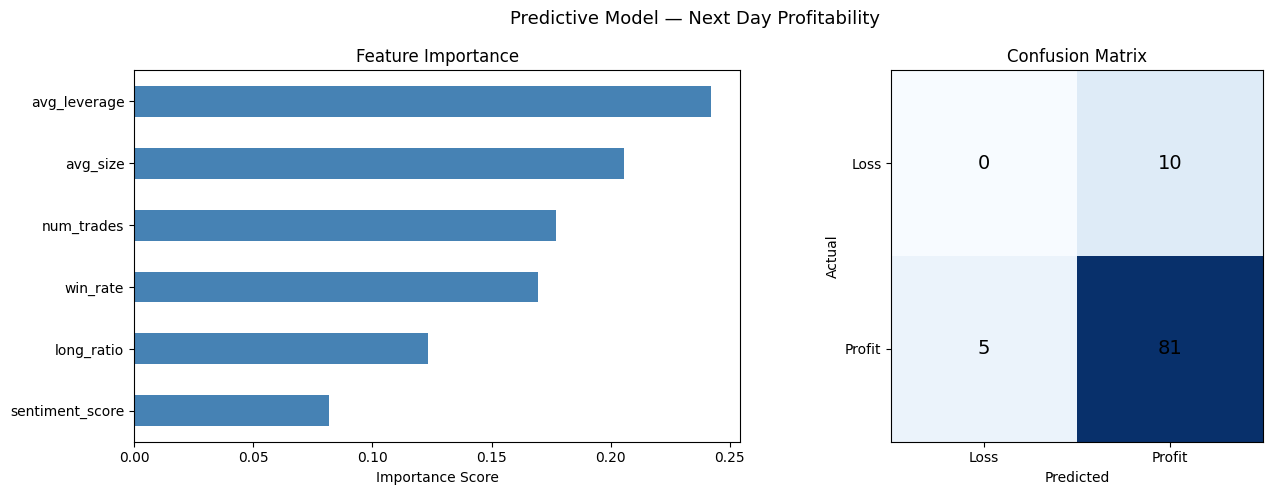


Cluster Summary:
             total_trades  win_rate  avg_leverage  avg_size  long_ratio  \
Archetype 0      40184.00      0.43           1.0   1844.21        0.31   
Archetype 1       4228.89      0.36           1.0   4413.42        0.18   
Archetype 2       7026.20      0.48           1.0   3696.86        0.74   
Archetype 3       8219.33      0.40           1.0  24666.44        0.69   

             total_pnl  
Archetype 0  836080.55  
Archetype 1  295828.72  
Archetype 2  296407.45  
Archetype 3  390628.98  


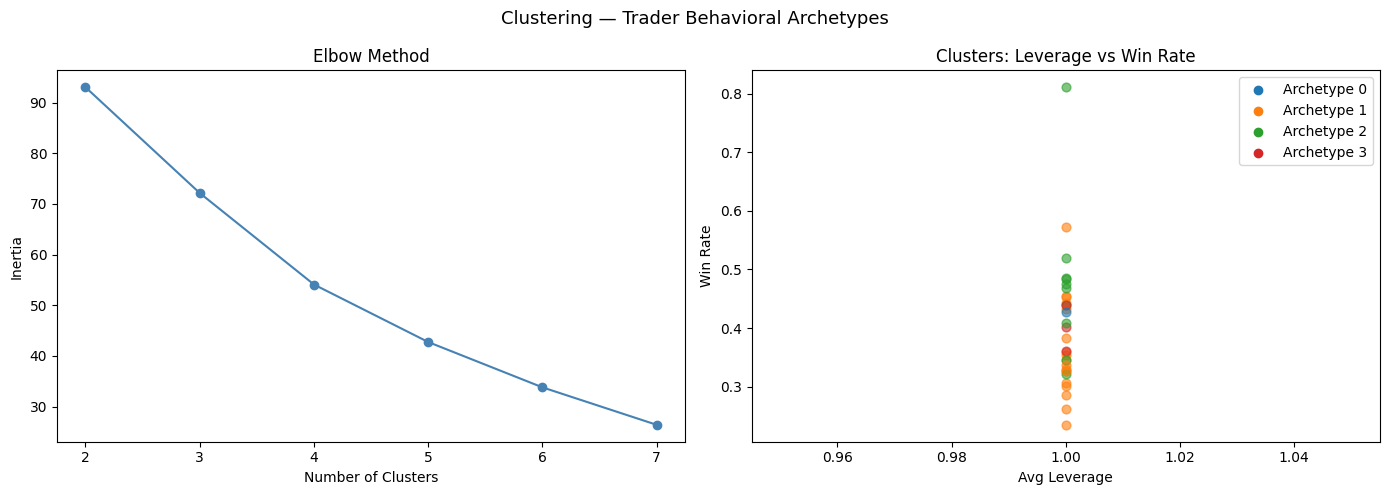


Saved: account_clusters.csv, daily_features.csv


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

fg = pd.read_csv('fear_greed_index.csv')
hd = pd.read_csv('historical_data.csv')

fg['date'] = pd.to_datetime(fg['date'])
hd['date'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
hd['date'] = pd.to_datetime(hd['date'])

merged = hd.merge(fg[['date', 'value', 'classification']], on='date', how='left')
merged['is_win']   = merged['Closed PnL'] > 0
merged['is_long']  = merged['Direction'].str.contains('Long',  na=False)
merged['is_short'] = merged['Direction'].str.contains('Short', na=False)
merged['leverage'] = merged['Size USD'] / merged.groupby('Account')['Size USD'].transform('mean')
merged['sentiment_score'] = merged['classification'].map({
    'Extreme Fear': 1, 'Fear': 2, 'Neutral': 3, 'Greed': 4, 'Extreme Greed': 5
})



# PART 1  PREDICTIVE MODEL
# Predict next-day PnL bucket (Profit / Loss) using sentiment + behavior


daily = merged.groupby('date').agg(
    total_pnl       = ('Closed PnL',       'sum'),
    num_trades      = ('Closed PnL',       'count'),
    win_rate        = ('is_win',           'mean'),
    avg_leverage    = ('leverage',         'mean'),
    avg_size        = ('Size USD',         'mean'),
    long_ratio      = ('is_long',          'mean'),
    sentiment_score = ('sentiment_score',  'mean'),
).reset_index().sort_values('date')

# target: was next day profitable?
daily['next_day_pnl']    = daily['total_pnl'].shift(-1)
daily['target']          = (daily['next_day_pnl'] > 0).astype(int)  # 1 = profit, 0 = loss
daily = daily.dropna()

features = ['sentiment_score', 'num_trades', 'win_rate', 'avg_leverage', 'avg_size', 'long_ratio']
X = daily[features]
y = daily['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Loss Day', 'Profit Day']))

# feature importance
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Predictive Model — Next Day Profitability', fontsize=13)

importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance Score')

cm = confusion_matrix(y_test, y_pred)
axes[1].imshow(cm, cmap='Blues')
axes[1].set_title('Confusion Matrix')
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Loss', 'Profit']); axes[1].set_yticklabels(['Loss', 'Profit'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, color='black')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()



# PART 2 —CLUSTERING (Behavioral Archetypes)


account_stats = merged.groupby('Account').agg(
    total_trades = ('Closed PnL', 'count'),
    win_rate     = ('is_win',     'mean'),
    avg_leverage = ('leverage',   'mean'),
    avg_size     = ('Size USD',   'mean'),
    total_pnl    = ('Closed PnL', 'sum'),
    long_ratio   = ('is_long',    'mean'),
).reset_index()

scaler = StandardScaler()
features_clust = ['total_trades', 'win_rate', 'avg_leverage', 'avg_size', 'long_ratio']
X_scaled = scaler.fit_transform(account_stats[features_clust])

# elbow method
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in range(2, 8)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Clustering — Trader Behavioral Archetypes', fontsize=13)

axes[0].plot(range(2, 8), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
account_stats['cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = account_stats.groupby('cluster')[features_clust + ['total_pnl']].mean().round(2)
cluster_summary.index = ['Archetype ' + str(i) for i in cluster_summary.index]
print("\nCluster Summary:")
print(cluster_summary)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, row in account_stats.iterrows():
    axes[1].scatter(row['avg_leverage'], row['win_rate'],
                    color=colors[row['cluster']], alpha=0.6, s=40)
axes[1].set_title('Clusters: Leverage vs Win Rate')
axes[1].set_xlabel('Avg Leverage')
axes[1].set_ylabel('Win Rate')
for c in range(4):
    axes[1].scatter([], [], color=colors[c], label=f'Archetype {c}')
axes[1].legend()

plt.tight_layout()
plt.show()

account_stats.to_csv('account_clusters.csv', index=False)
daily.to_csv('daily_features.csv', index=False)
print("\nSaved: account_clusters.csv, daily_features.csv")